# ***Flight Fare Prediction***

## **Step 1 : Import Libraries**



* **Data Handling** – pandas, numpy → Used for loading, cleaning, and manipulating flight data.
* **Visualization** – seaborn, matplotlib → Used for creating charts and graphical analysis of data.
* **Utility** – warnings.filterwarnings('ignore') → Used to suppress unnecessary warning messages.
* **Preprocessing** – train_test_split → Used to divide the dataset into training and testing sets.
* **Machine Learning Models** – LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor, XGBRegressor → Used to build and compare different regression models for flight fare prediction.
* **Hyperparameter Tuning** – RandomizedSearchCV → Used to optimize model parameters and improve prediction performance.
* **Evaluation Metrics** – MAE, MSE, RMSE, R² Score → Used to evaluate the accuracy and performance of regression models.
* **XGBoost Library** – XGBRegressor → Used for advanced gradient boosting with high prediction accuracy and efficiency.


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
%matplotlib inline

## *Step 2: Load the Dataset*


* **Dataset Loading** – Used pandas to import the Flight Fare Prediction dataset into a DataFrame for analysis, preprocessing, and model building.



In [114]:
df = pd.read_excel("Flight_Fare.xlsx")

In [115]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [116]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [117]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [118]:
df.describe(include='O').T

,count,unique,top,freq
Airline,10683,12,Jet Airways,3849
Date_of_Journey,10683,44,18/05/2019,504
Source,10683,5,Delhi,4537
Destination,10683,6,Cochin,4537
Route,10682,128,DEL → BOM → COK,2376
Dep_Time,10683,222,18:55,233
Arrival_Time,10683,1343,19:00,423
Duration,10683,368,2h 50m,550
Total_Stops,10682,5,1 stop,5625
Additional_Info,10683,10,No info,8345


In [119]:
df.isnull()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,False,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,False


In [120]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [122]:
df.shape

(10683, 11)

## **Step 3: Data Cleaning**

* **Data Cleaning** – Checked for missing values in the dataset. Since only one record contained missing values in the Route and Total_Stops columns, the row was removed to maintain data consistency and ensure accurate model training.


In [123]:
df.dropna(inplace=True)

In [124]:
df.duplicated().sum()

np.int64(220)

In [125]:
df.drop_duplicates(inplace=True)

In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

## **Step 4: Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify missing values and outliers, analyze feature distributions, and discover relationships between variables. The insights obtained from EDA help in selecting appropriate preprocessing techniques and building an effective machine learning model.

* Examined the dataset using **Pandas Profiling (YData Profiling)** to generate a comprehensive overview of data quality, distributions, and relationships.
* Identified **numerical and categorical features** for separate analysis.
* Visualized numerical variables using **Histograms** to understand data distribution and detect skewness.
* Used **Box Plots** to identify outliers and analyze the spread of numerical data.
* Analyzed categorical features such as **Airline, Source, Destination, Total Stops, and Additional Information** using **Count Plots**.
* Compared the distribution of flights across different **Source** and **Destination** locations.
* Studied the frequency distribution of airlines and stop categories to understand travel patterns.
* Generated a **Correlation Heatmap** to examine relationships among numerical features and their impact on flight prices.



In [128]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="EDA Report", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [129]:
# Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Price'], dtype='object')

Categorical Columns:
Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info'],
      dtype='object')


#### Observation
• The Price distribution is positively skewed.                                                    
• Most flight ticket prices are concentrated in the lower price range, while only a few tickets are highly expensive.
• This indicates the presence of outliers, which may affect regression models.

#### Implication
Since the Price column contains extreme values, outlier treatment (Winsorization) was applied to improve model stability and prediction accuracy.

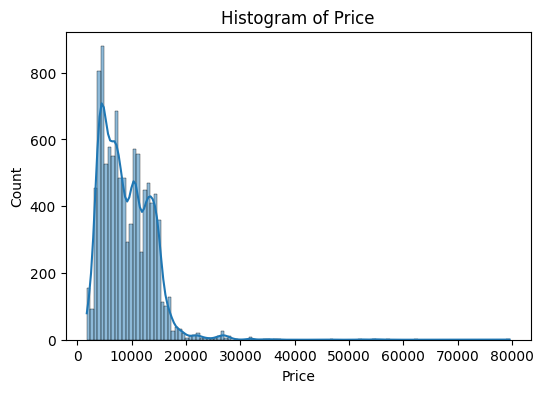

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

#### Observation
- Several outliers are present in the Price column. 
- These represent unusually expensive flight fares.

#### Implication
Extreme values can influence regression models and increase prediction error. Therefore, Winsorization was applied to reduce the impact of these outliers while preserving all observations.

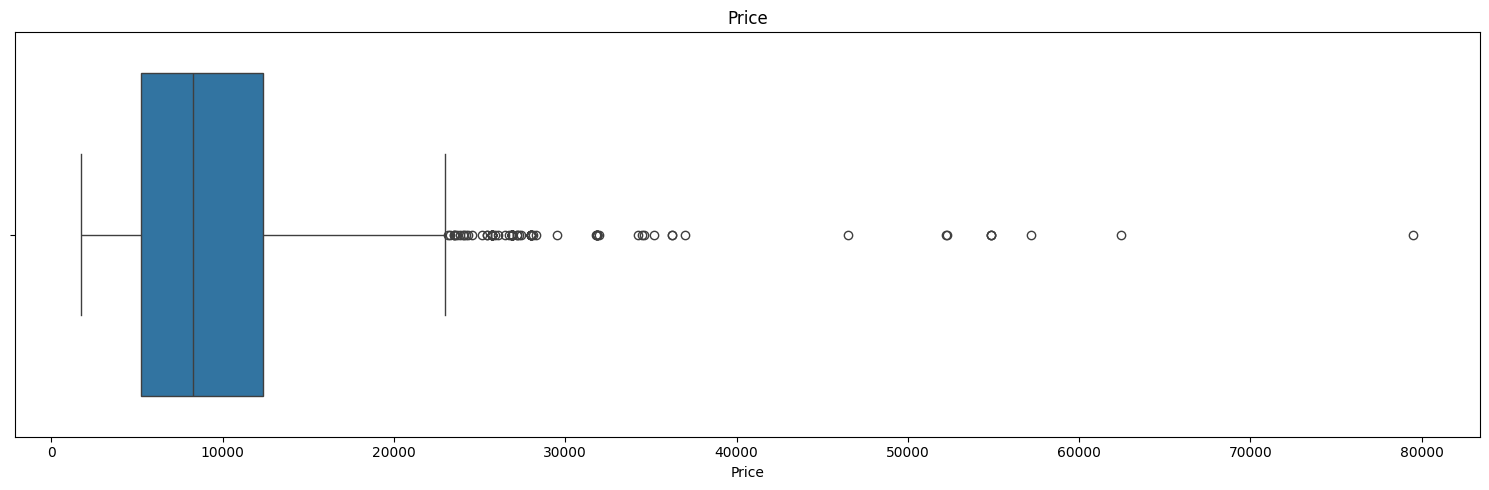

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Observation
- The count plots show the distribution of categorical features in the dataset.
- Some airlines have significantly more flights than others, indicating that the dataset is not evenly distributed across airlines.
- Certain source and destination cities appear more frequently, suggesting that some routes are more common.
- Most flights have either non-stop or one stop, while flights with multiple stops are less frequent.
- The Additional_Info column is dominated by a few categories, with many records containing similar information.

#### Implication

The categorical variables show considerable variation in their distributions, indicating that they contain useful information for predicting flight prices. Since machine learning algorithms require numerical input, these categorical features will be encoded during preprocessing and used as important predictors in the regression models.


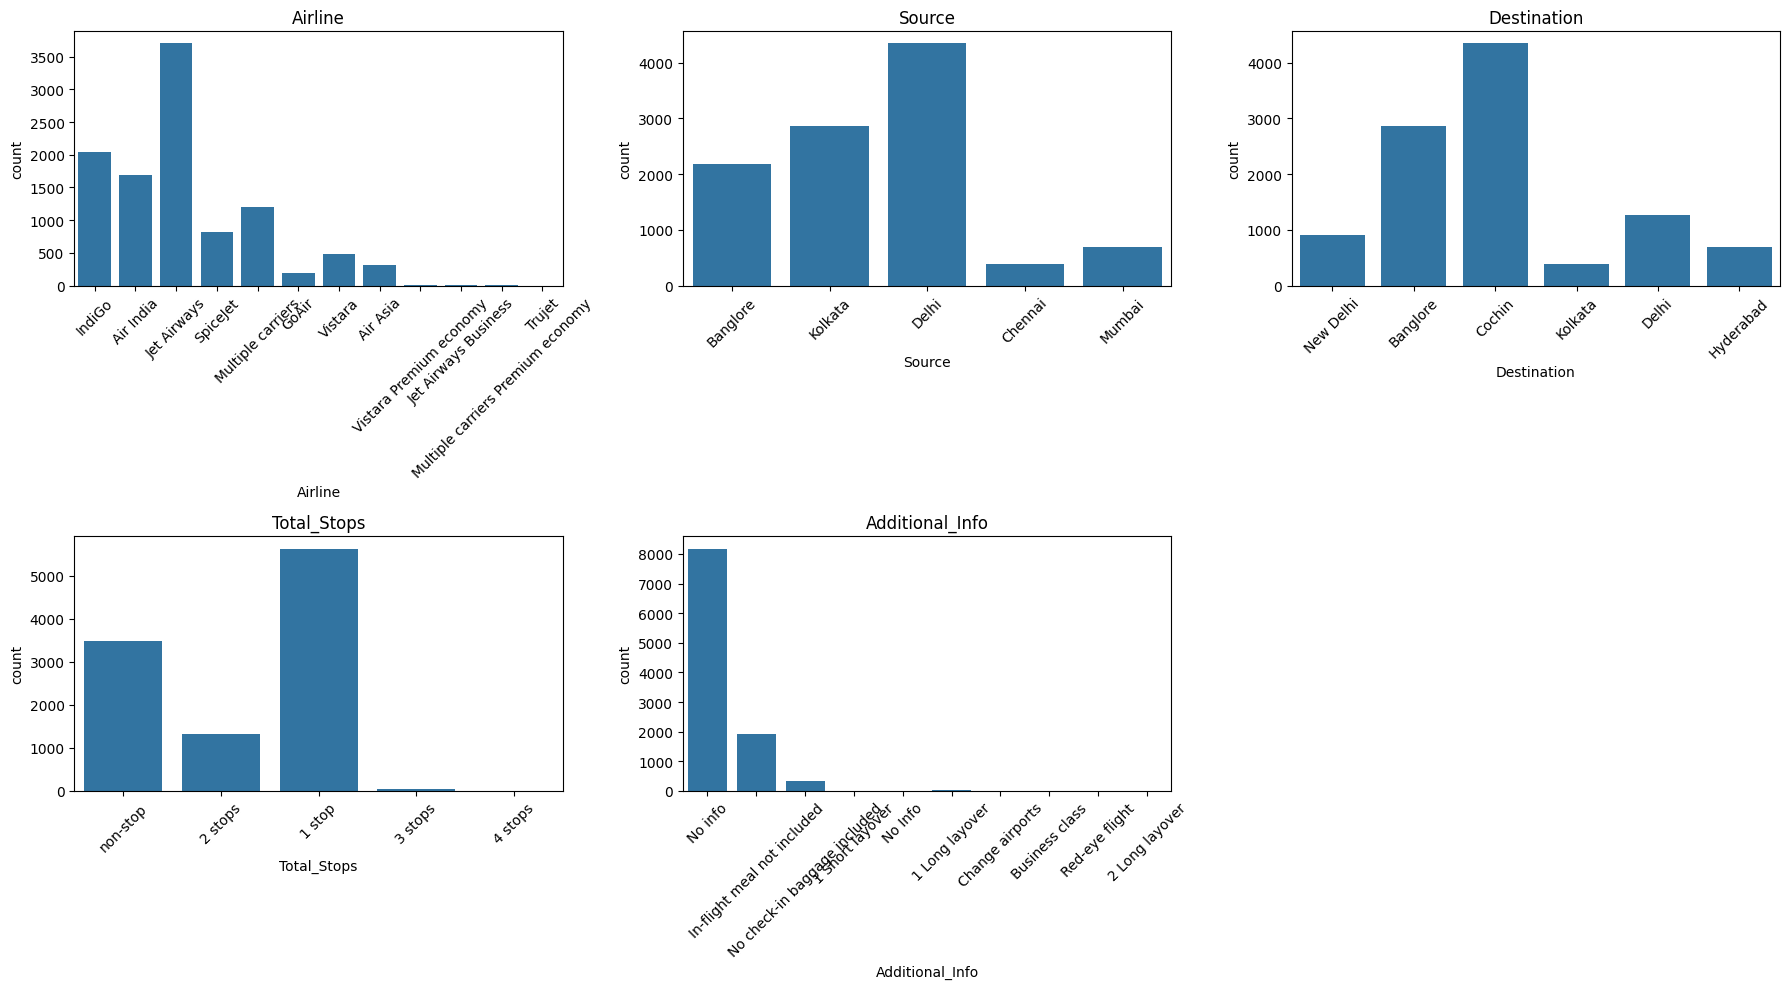

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,10))

cols = ['Airline','Source','Destination',
        'Total_Stops','Additional_Info']

for i, col in enumerate(cols, 1):
    plt.subplot(2,3,i)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

#### Observation

The box plots compare the distribution of flight prices across different categorical features.

- Airline: Flight prices vary significantly across airlines. Premium airlines generally have higher median ticket prices, while low-cost airlines have lower fares. 
- Source: Flights departing from different source cities show variations in ticket prices, indicating that the departure location influences airfare.
- Destination: Ticket prices differ across destination cities, suggesting that travel demand and route distance affect pricing.
- Total Stops: Flights with more stops generally have higher ticket prices. This indicates a positive relationship between the number of stops and the fare.
- Additional_Info: Most categories show similar price distributions, suggesting that this feature has a relatively smaller impact on flight prices compared to Airline and Total Stops.

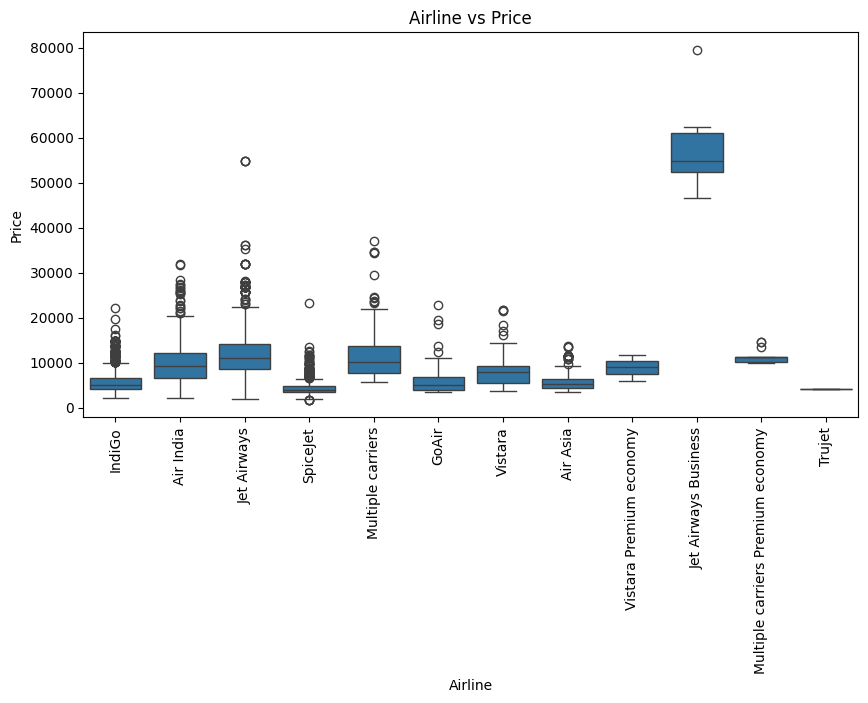

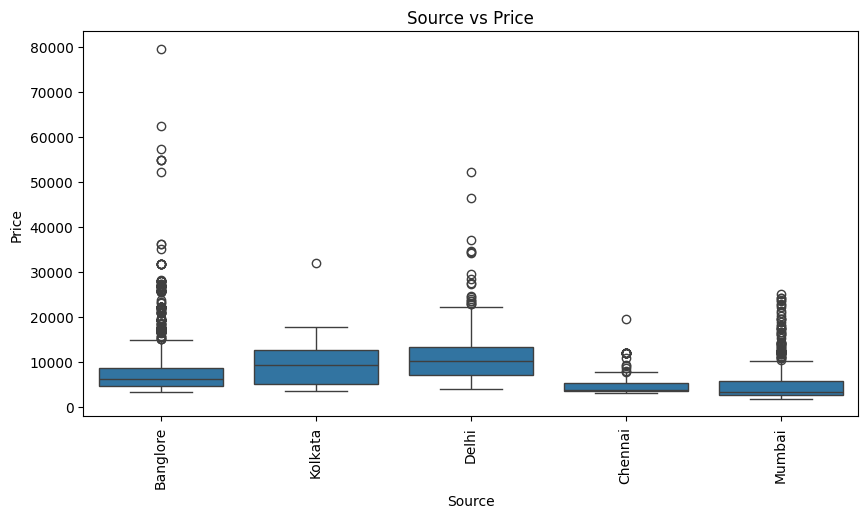

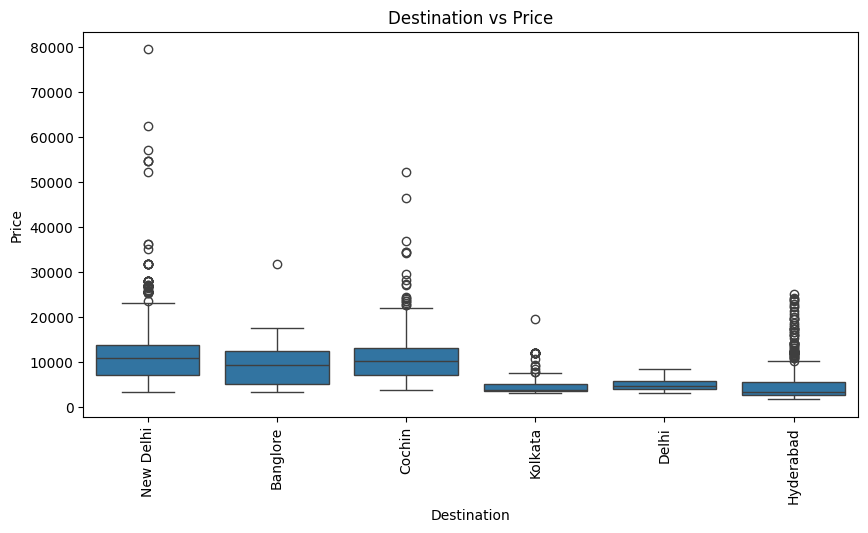

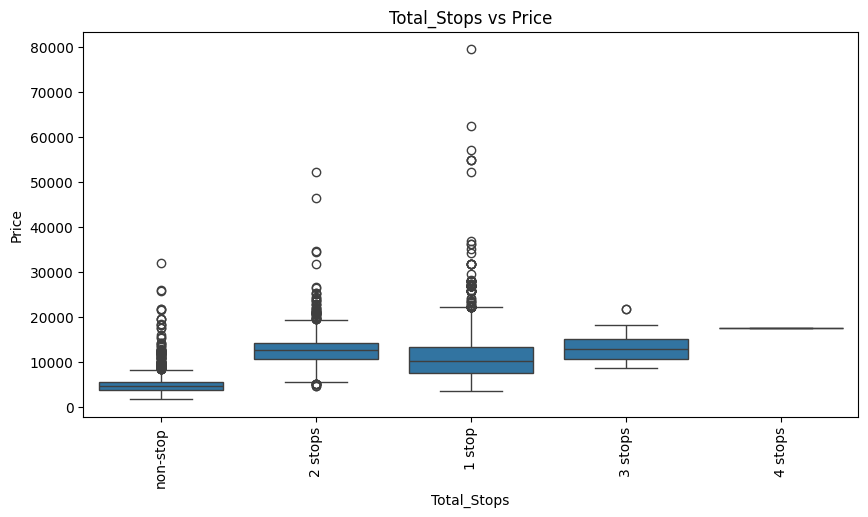

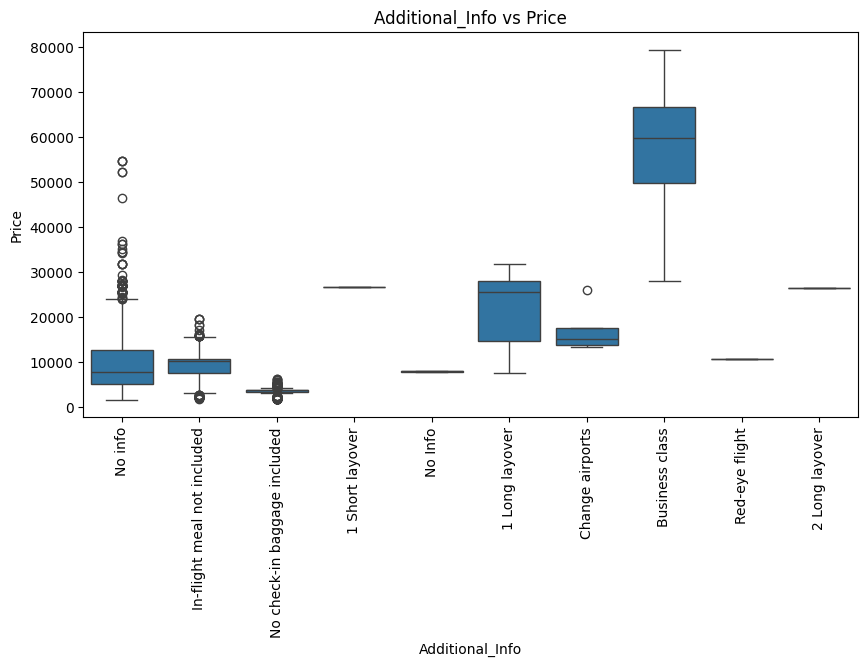

In [133]:
# for categorical data
columns = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Additional_Info'
]

for col in columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y='Price', data=df)
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=90)
    plt.show()

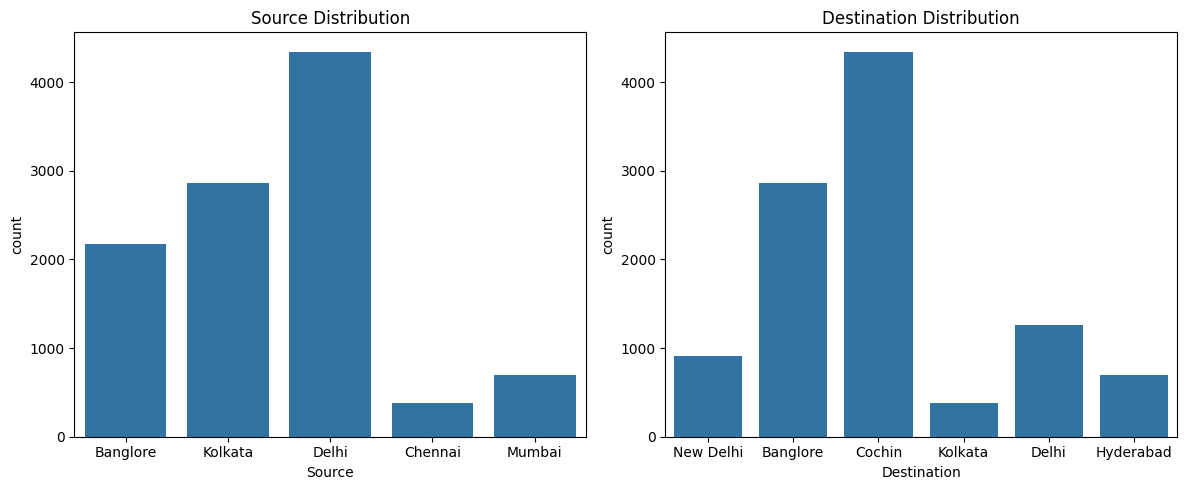

In [134]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x='Source', data=df)
plt.title('Source Distribution')

plt.subplot(1,2,2)
sns.countplot(x='Destination', data=df)
plt.title('Destination Distribution')

plt.tight_layout()
plt.show()

#### Observation
- The heatmap displays the correlation coefficients between the top 20 numerical features.
- Features with correlation values close to +1 have a strong positive relationship, while values close to -1 indicate a strong negative relationship.
- Features with higher correlation to Price are more influential in predicting flight fares.
- Some features show very weak correlations, indicating they contribute less to price prediction.

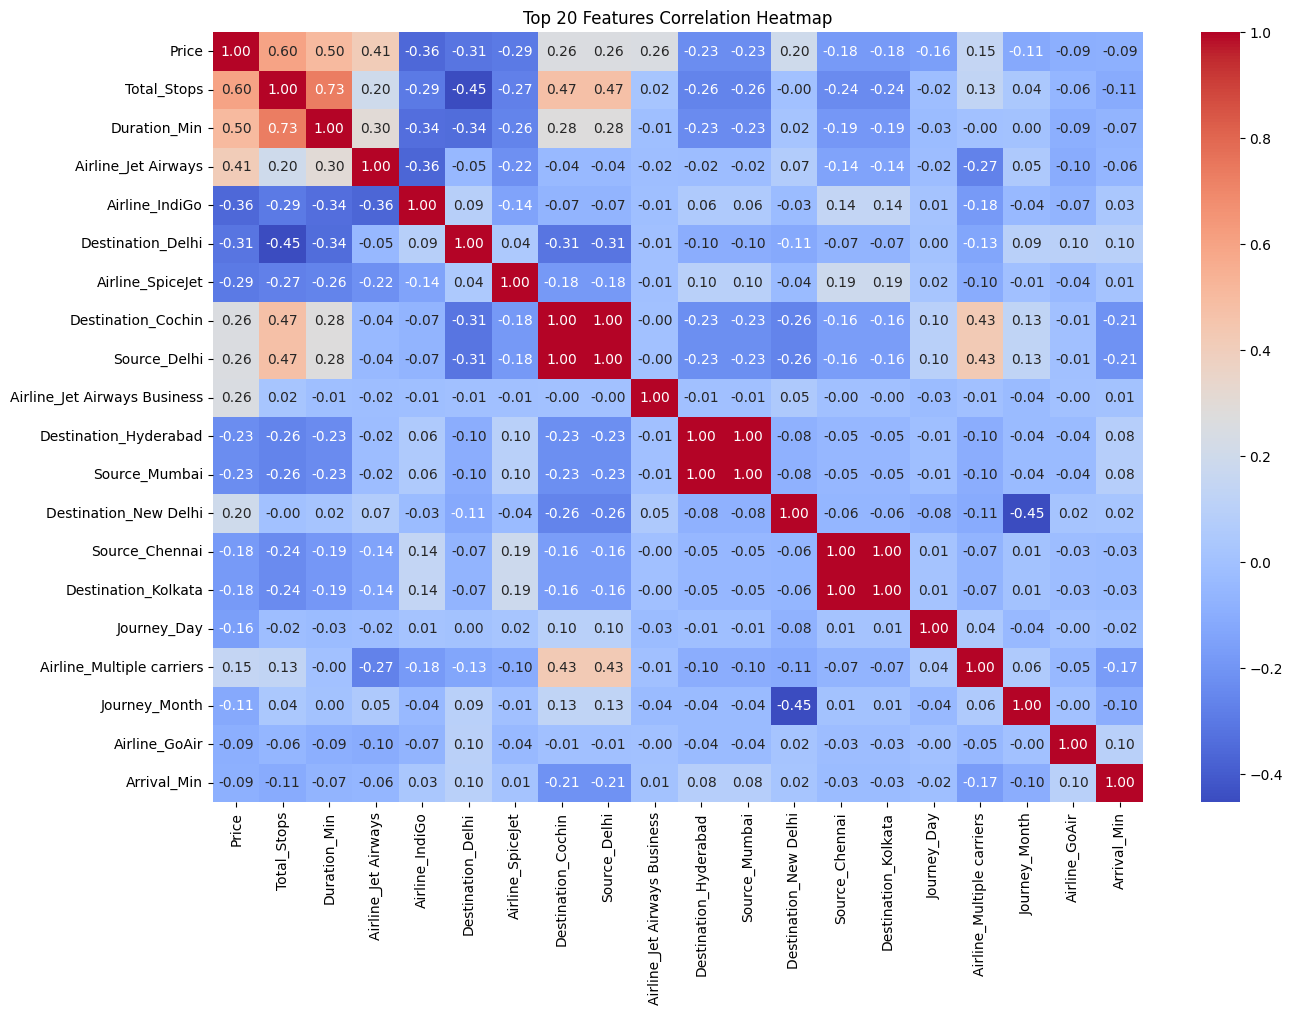

In [142]:
corr_matrix = df.corr(numeric_only=True)

top_features = corr_matrix['Price'].abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(15,10))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Top 20 Features Correlation Heatmap')
plt.show()

## **Step 5: Feature Engineering & Preprocessing**

* Extracted **Journey Day** and **Journey Month** from the Date_of_Journey column and removed the original date column.
* Extracted **Departure Hour** and **Departure Minute** from the Dep_Time column.
* Extracted **Arrival Hour** and **Arrival Minute** from the Arrival_Time column.
* Converted the Duration column into **Total Duration (Minutes)** for easier numerical analysis.
* Transformed the Total_Stops column into numerical values for machine learning compatibility.
* Created a new column Route_Count by counting the number of segments in the Route (splitting by '→') and then dropped the original Route column.
* Dropped the Additional_Info column as it wasn't useful.
* Applied **One-Hot Encoding** to categorical features like Airline, Source, and Destination.
* Converted all features into numerical format suitable for machine learning models.
* Defined **Price** as the target variable and selected the remaining columns as input features.
* Split the data into **training** and **testing** sets using train_test_split.
* The dataset is now ready for model training and evaluation.


In [136]:
#Convert journey date into day and month.
df["Journey_Day"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
).dt.day

df["Journey_Month"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
).dt.month

df.drop("Date_of_Journey",axis=1,inplace=True)

### Dep_Time

In [137]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_Min'] = pd.to_datetime(df['Dep_Time']).dt.minute
df.drop('Dep_Time', axis=1, inplace=True)

### Arrival_Time

In [138]:
df["Arrival_Time"] = df["Arrival_Time"].str.split(" ").str[0]

df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time",axis=1,inplace=True)

### Duration

In [139]:
def duration_to_mins(x):

    h=0
    m=0

    if 'h' in x:
        h=int(x.split('h')[0])

    if 'm' in x:

        if 'h' in x:
            m=int(
                x.split('h')[1]
                .replace('m','')
                .strip()
            )

        else:
            m=int(
                x.replace('m','')
                .strip()
            )

    return h*60+m

df["Duration_Min"] = df["Duration"].apply(duration_to_mins)

df.drop("Duration",axis=1,inplace=True)

### Convert Total_Stops into Numbers

In [140]:
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

df['Total_Stops'] = pd.to_numeric(df['Total_Stops'])

### one hot encoding

In [141]:
df = pd.get_dummies(
    df,
    columns=['Airline','Source','Destination'],
    drop_first=True
)

In [143]:
df['Route'].value_counts()

Route
DEL → BOM → COK          2376
BLR → DEL                1536
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → CCU → HYD             1
BOM → BBI → HYD             1
Name: count, Length: 128, dtype: int64

In [144]:
df['Route_Count'] = df['Route'].apply(lambda x: len(str(x).split('→')))
df.drop('Route', axis=1, inplace=True)

In [145]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [146]:
df.drop(['Additional_Info'], axis=1, inplace=True)

In [147]:
df.shape

(10462, 30)

### Removing outliers
* **Outlier Handling** – Applied **Winsorization** on the Price column to cap extreme values and reduce the impact of outliers while preserving all records in the dataset.


In [148]:
from scipy.stats.mstats import winsorize

df['Price_Winsorized'] = winsorize(
    df['Price'],
    limits=[0.01, 0.01])
print("Original Max Price :", df['Price'].max())
print("Winsorized Max Price :", df['Price_Winsorized'].max())

print("Original Min Price :", df['Price'].min())
print("Winsorized Min Price :", df['Price_Winsorized'].min())

Original Max Price : 79512
Winsorized Max Price : 22270
Original Min Price : 1759
Winsorized Min Price : 2227



* Built and trained multiple regression models including **Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost**.
* Applied **RandomizedSearchCV** to optimize model hyperparameters and improve prediction accuracy.
* Evaluated and compared all models using **MAE, RMSE, and R² Score** to select the best-performing model.



In [149]:
X = df.drop('Price', axis=1)
y = df['Price']
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (10462, 30)
y shape: (10462,)


## *Step 6: Train and Test Split*

Before training the machine learning models, the dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate how well the trained models perform on unseen data. This helps measure the model's ability to generalize and reduces the risk of overfitting.

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [151]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [152]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


## Step 7: Model Building

* Built and trained multiple regression models including **Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost**.
* Applied **RandomizedSearchCV** to optimize model hyperparameters and improve prediction accuracy.
* Evaluated and compared all models using **MAE, RMSE, and R² Score** to select the best-performing model.

## Linear regression

In [153]:
lr = LinearRegression()

In [154]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [155]:
y_pred_lr = lr.predict(X_test)

In [156]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score :", r2_score(y_test, y_pred_lr))

MAE : 208.52622030412212
RMSE : 886.9215411522633
R2 Score : 0.9622724511703171


### After applying hyperparameter tunning

In [157]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Best Parameters:", grid_ridge.best_params_)
best_ridge = grid_ridge.best_estimator_

y_pred = best_ridge.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

Best Parameters: {'alpha': 0.1}
MAE : 209.8803934724457
RMSE : 886.740355045229
R2 Score : 0.9622878640544603


## Decision tree

In [158]:
dt = DecisionTreeRegressor(random_state=42)

In [159]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [160]:
y_pred_dt = dt.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score :", r2_score(y_test, y_pred_dt))

MAE : 47.72527472527472
RMSE : 769.4342704300241
R2 Score : 0.971605695493827


### After applying hyperparameter tunning

In [161]:
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['squared_error', 'friedman_mse']
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

y_pred = best_dt.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
MAE : 52.62048119394845
RMSE : 717.5473486787479
R2 Score : 0.9753061212108709


## Random Forest Regressor

In [162]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("RandomForestRegressor")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

RandomForestRegressor
MAE : 41.34809199599572
RMSE : 698.0589896730302
R2 Score : 0.9766292616830903


### After applying hyperparameter tunning

In [163]:
rf = RandomForestRegressor(random_state=42)
params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 :", r2_score(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
MAE : 234.77045107592812
RMSE : 838.6252097999851
R2 : 0.9662694043107627


## Gradient Boosting

In [164]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred_gbr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R2 Score :", r2_score(y_test, y_pred_gbr))

MAE : 70.47018101394188
RMSE : 735.513283097521
R2 Score : 0.9740540710440609


### After applying hyperparameter tunning

In [165]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 50.67114598847378
RMSE : 694.2035624293986
R2 Score : 0.9768867051277896


## Xgboosting

In [166]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score :", r2_score(y_test, y_pred_xgb))

MAE : 71.36114501953125
RMSE : 631.7214823401212
R2 Score : 0.9808601140975952


In [167]:
print(df['Total_Stops'].dtype)

int64


### After applying hyperparameter tunning

In [168]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 0.7, 'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
MAE : 71.79776000976562
RMSE : 654.2272397645943
R2 Score : 0.9794720411300659


### Feature Importance 

In [169]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

print(importance)

                         Feature  Importance
12  Airline_Jet Airways Business    0.366675
29              Price_Winsorized    0.358184
7                   Duration_Min    0.050580
10                Airline_IndiGo    0.041768
0                    Total_Stops    0.029031
27         Destination_New Delhi    0.025120
28                   Route_Count    0.022603
11           Airline_Jet Airways    0.018897
1                    Journey_Day    0.014140
8              Airline_Air India    0.012951


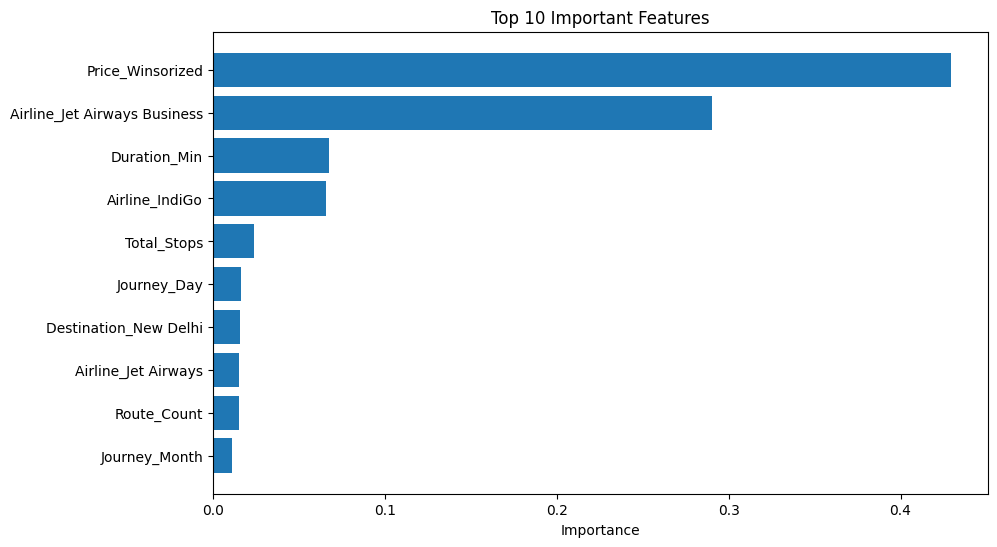

In [170]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'],
         importance['Importance'])

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

### Model Comparsion


 Multiple regression models were compared using MAE, RMSE, and R² Score to identify the best-performing model for flight fare prediction.


In [177]:
# Store all models in a dictionary
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

# Create comparison table
comparison = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R² Score"])

# Sort by R² Score (Highest is Best)
comparison = comparison.sort_values(by="R² Score", ascending=False)

# Display comparison table
comparison


,Model,MAE,RMSE,R² Score
4,XGBoost,71.361145,631.721482,0.980860
3,Gradient Boosting,50.671146,694.203562,0.976887
2,Random Forest,41.605985,700.858867,0.976441
1,Decision Tree,47.725275,769.434270,0.971606
0,Linear Regression,208.526220,886.921541,0.962272


## Save the model 

In [173]:
import pickle

# Save the best model
with open('flight_fare_model.pkl', 'wb') as file:
    pickle.dump(xgb, file)

print("Model saved successfully!")

Model saved successfully!


## Load the model

In [174]:
import pickle

with open('flight_fare_model.pkl', 'rb') as file:
    model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


 **Among all the machine learning models evaluated, XGBoost Regressor achieved the highest R² score and the lowest prediction error, making it the best-performing model for flight fare prediction.**

# Challenges Faced

- Handling missing values, duplicate records, and outliers.
- Converting date, time, and duration into numerical features.
- Encoding categorical variables for machine learning.
- Performing feature engineering to improve prediction accuracy.
- Training, comparing, and tuning multiple regression models.
- Selecting XGBoost as the best-performing model based on evaluation metrics.

# **Conclusion**

* Successfully cleaned, analyzed, and preprocessed the flight fare dataset to prepare it for machine learning.
* Built and compared multiple regression models, including **Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost**.
* Applied **hyperparameter tuning** to improve model performance and prediction accuracy.
* Evaluated models using **MAE, RMSE, and R² Score** metrics.
* Identified the best-performing model based on evaluation results.
* Developed a reliable system capable of predicting flight ticket prices using factors such as airline, route, duration, source, destination, and number of stops.
* The project demonstrates how machine learning can help travelers and airlines make better pricing and booking decisions.
